In [1]:
import pandas as pd

stats = pd.read_csv("Seasons_Stats.csv")
players = pd.read_csv("Players.csv")

print("Seasons_Stats shape:", stats.shape)
print("Players shape:", players.shape)

stats.head()

Seasons_Stats shape: (24691, 53)
Players shape: (3922, 8)


,Unnamed: 0,Year,Player,Pos,Age,Tm,G,GS,MP,PER,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,0,1950.0,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,NaN,...,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1,1950.0,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,NaN,...,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,2,1950.0,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,NaN,...,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0
3,3,1950.0,Ed Bartels,F,24.0,TOT,15.0,NaN,NaN,NaN,...,0.559,NaN,NaN,NaN,20.0,NaN,NaN,NaN,29.0,63.0
4,4,1950.0,Ed Bartels,F,24.0,DNN,13.0,NaN,NaN,NaN,...,0.548,NaN,NaN,NaN,20.0,NaN,NaN,NaN,27.0,59.0


In [2]:
stats.isnull().sum()

,0
Unnamed: 0,0
Year,67
Player,67
Pos,67
Age,75
Tm,67
G,67
GS,6458
MP,553
PER,590


In [3]:
print("Duplicate rows:", stats.duplicated().sum())

Duplicate rows: 0


In [4]:
stats = stats[stats["Year"] >= 1980]
print(stats.shape)

(18927, 53)


In [5]:
stats = stats.drop(columns=["blanl", "blank2"])
print(stats.shape)

(18927, 51)


In [6]:
stats = stats.drop(columns=["Unnamed: 0"])
print(stats.shape)

(18927, 50)


In [7]:
stats = stats.dropna(subset=["Player"])
print(stats.shape)

(18927, 50)


In [8]:
career_points = stats.groupby("Player")["PTS"].sum().sort_values(ascending=False)
print(career_points.head(10))

Player
Karl Malone*          36928.0
Kobe Bryant           33643.0
Michael Jordan*       32292.0
Dirk Nowitzki         30260.0
Eddie Johnson         29779.0
Shaquille O'Neal*     29428.0
LeBron James          28787.0
Dominique Wilkins*    28591.0
Vince Carter          27463.0
Allen Iverson*        27457.0
Name: PTS, dtype: float64


In [9]:
points_by_year = stats.groupby("Year")["PTS"].mean()
print(points_by_year)

Year
1980.0    612.425770
1981.0    592.977961
1982.0    591.873995
1983.0    568.639386
1984.0    616.714286
1985.0    588.911602
1986.0    568.503958
1987.0    570.433862
1988.0    528.791080
1989.0    550.333333
1990.0    546.993464
1991.0    566.308390
1992.0    525.275109
1993.0    534.447661
1994.0    497.937630
1995.0    520.506637
1996.0    477.295413
1997.0    436.834495
1998.0    457.634369
1999.0    276.938856
2000.0    484.679435
2001.0    450.566108
2002.0    482.726000
2003.0    494.349896
2004.0    428.497436
2005.0    452.499145
2006.0    458.216696
2007.0    496.916667
2008.0    449.512605
2009.0    468.245704
2010.0    468.425606
2011.0    449.953600
2012.0    364.622505
2013.0    448.427574
2014.0    441.872340
2015.0    428.067588
2016.0    465.636678
2017.0    474.732773
Name: PTS, dtype: float64


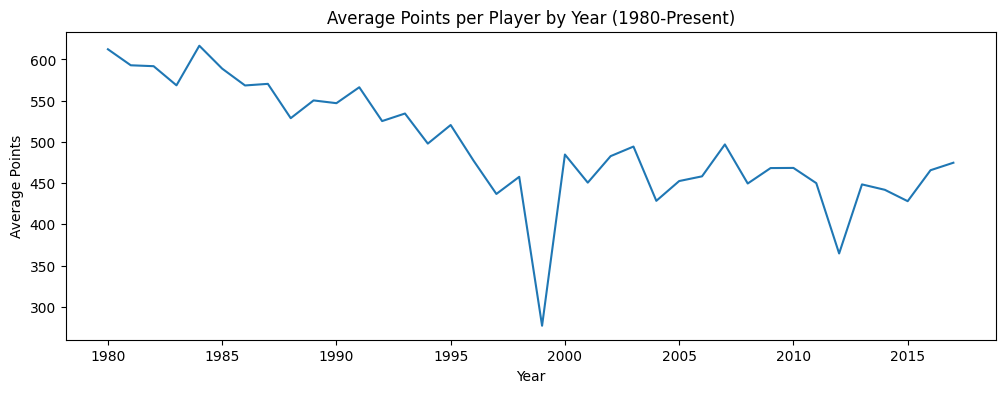

In [10]:
import matplotlib.pyplot as plt

points_by_year.plot(kind="line", figsize=(12,4))
plt.title("Average Points per Player by Year (1980-Present)")
plt.xlabel("Year")
plt.ylabel("Average Points")
plt.show()

In [11]:
ppg_by_year = (stats.groupby("Year")["PTS"].sum() / stats.groupby("Year")["G"].sum())

In [12]:
print(ppg_by_year)

Year
1980.0    11.048919
1981.0    10.695702
1982.0    10.522330
1983.0    10.330731
1984.0    10.529268
1985.0    10.625299
1986.0    10.479718
1987.0    10.555833
1988.0    10.365590
1989.0    10.397084
1990.0    10.284275
1991.0    10.425900
1992.0    10.098052
1993.0    10.132030
1994.0     9.891303
1995.0     9.976635
1996.0     9.670112
1997.0     9.411921
1998.0     9.322087
1999.0     8.817936
2000.0     9.440448
2001.0     9.171525
2002.0     9.471902
2003.0     9.426784
2004.0     9.125928
2005.0     9.427401
2006.0     9.439988
2007.0     9.668150
2008.0     9.533756
2009.0     9.793330
2010.0     9.760978
2011.0     9.571526
2012.0     9.101934
2013.0     9.110697
2014.0     9.445615
2015.0     9.313904
2016.0     9.471354
2017.0     9.801721
dtype: float64


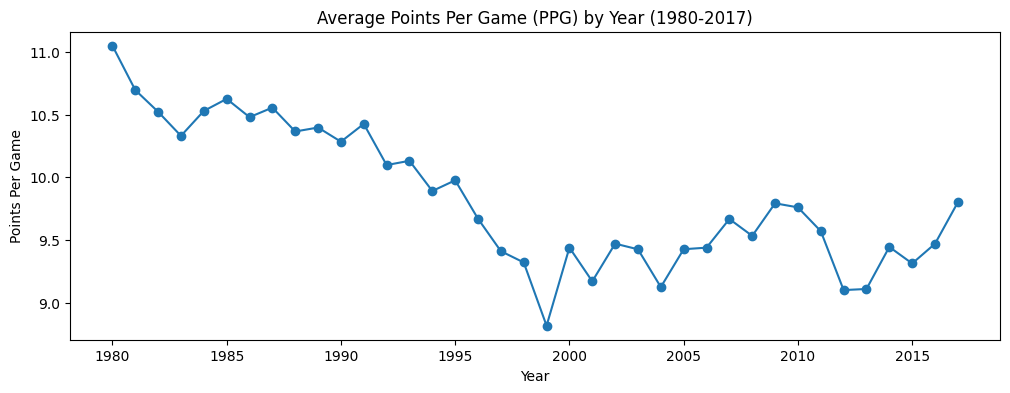

In [13]:
import matplotlib.pyplot as plt

ppg_by_year.plot(kind="line", figsize=(12,4), marker="o")
plt.title("Average Points Per Game (PPG) by Year (1980-2017)")
plt.xlabel("Year")
plt.ylabel("Points Per Game")
plt.show()

In [14]:
import sqlite3

conn = sqlite3.connect(":memory:")
stats.to_sql("nba_stats", conn, index=False, if_exists="replace")

18927

In [15]:
query = """
SELECT Tm, SUM(PTS) as total_points, COUNT(DISTINCT Player) as num_players
FROM nba_stats
GROUP BY Tm
ORDER BY total_points DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
print(result)


    Tm  total_points  num_players
0  TOT      638568.0         1145
1  DEN      326751.0          286
2  PHO      325707.0          288
3  GSW      324918.0          332
4  LAL      324186.0          243
5  SAS      317601.0          309
6  POR      317429.0          263
7  BOS      317113.0          275
8  HOU      315274.0          285
9  UTA      312724.0          235


In [16]:
query = """
SELECT Tm, SUM(PTS) as total_points, COUNT(DISTINCT Player) as num_players
FROM nba_stats
WHERE Tm != 'TOT'
GROUP BY Tm
Order BY total_points DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
print(result)

    Tm  total_points  num_players
0  DEN      326751.0          286
1  PHO      325707.0          288
2  GSW      324918.0          332
3  LAL      324186.0          243
4  SAS      317601.0          309
5  POR      317429.0          263
6  BOS      317113.0          275
7  HOU      315274.0          285
8  UTA      312724.0          235
9  MIL      311932.0          309


In [17]:
stats.to_csv("nba_stats_cleaned.csv", index=False)

In [18]:
import os
print(os.listdir())

['.config', 'nba_stats_cleaned.csv', 'Players.csv', 'Seasons_Stats.csv', 'sample_data']
